In [57]:
from math import exp, log

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
class Value(object):
    """
    A class to represent a value.
    """
    def __init__(self, data, children=(), label=''):

        self.data = data
        self._op = ''
        self._prev = set[Value](children)
        self.grad = 0 # seed: ∂L/∂L = 1, base case of reverse-mode autodiff
        self.label = label

    def __str__(self):
        return str(Value=self.data)

    def __repr__(self):
        return f"Value(data={self.data})"


    def __add__(self, other):
        if not isinstance(other, Value): other = Value(other)


        value = Value(self.data + other.data, (self, other, ))
        value._op = '+'
        
        def _backward():
            # Gradient Accumulates
            self.grad += 1 * value.grad
            other.grad += 1 * value.grad

        # Give the child value backwards fuction to call... reason leaf nodes don't need it called
        value._backward = _backward

        return value

    
    def __mul__(self, other):
        if not isinstance(other, Value): other = Value(other)

        value = Value(self.data * other.data, (self, other, ))
        value._op = '*'

        def _backward():

            self.grad += other.data * value.grad
            other.grad += self.data * value.grad

        value._backward = _backward

        return value

    def tanh(self):
        
        value = Value((exp(2*self.data)-1)/(exp(2*self.data)+1), (self, ))
    
        value._op = "tanh"

        def _backward():
            self.grad += (1-value.data**2)*value.grad

        value._backward = _backward
        return value


    def __neg__(self):
        value = Value((-1)*self.data, (self, ))
        value._op = "neg"


        def _backward():
            # Effectively other.data = -1 for __mul__
            self.grad+= (-1)*value.grad

        value._backward = _backward

        return value

    def __sub__(self, other):
        if not isinstance(other, Value): other = Value(other)
        value = Value(self.data-other.data, (self, other, ))
        value._op = "-"

        def _backward():
            self.grad += 1*value.grad 
            other.grad += (-1)*value.grad

        value._backward = _backward

        return value
        
    def __radd__(self, other):
        return self+other

    def __rmul__(self, other):
        return self*other


    def __rsub__(self, other):
        return (-1)*self+other


    def __pow__(self, other):
        other_is_value= isinstance(other, Value)
        if not other_is_value: other = Value(other)

        value = Value(self.data**other.data, (self, other, ))
        value._op = "pow"

        def _backward():
            """
            a**b = c da/dc = b*a**(b-1), 

            db/dc = (a**(b+h) - a**b )/h =(a**b * a**h - a**b)/h = a**b(a**h-1)/h 

            lim h->0 (a**h-1)/h = ln(x=a) so db/dc = ln(a)*a**b 
            """
            self.grad += other.data*self.data**(other.data-1)*value.grad
            if other_is_value:
                assert self.data > 0
                other.grad += log(self.data)* value.data * value.grad 

        value._backward = _backward

        return value

    #def __truediv__(self, other)



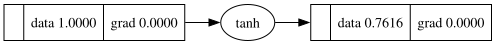

In [53]:
f = Value(1)
g = f.tanh()
draw_dot(g)

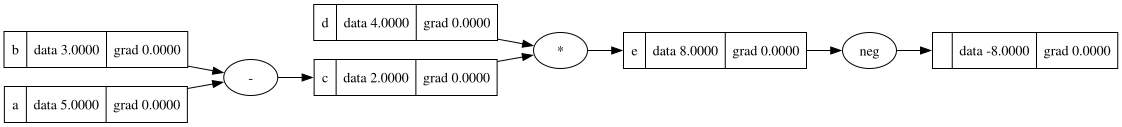

In [54]:
a = Value(5, label="a")
b = Value(3, label="b")
c = a - b; c.label = "c"
d = Value(4, label="d")
e = c*d; e.label = "e"
f = -e
draw_dot(f)

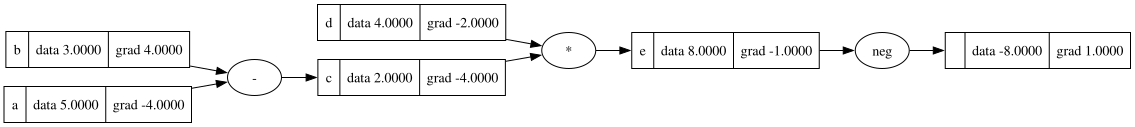

In [55]:
f.grad = 1
f._backward()
e._backward()
c._backward()
draw_dot(f)

In [ ]:
"""
da/de = da/dc * dc/da

c = a - b means da/dc = 1 db/db = -1

c = a * b means da/dc = b, db/db = a

"""